In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("1. Loading Data dari Pipeline Pentaho...")
# UPDATE: Langsung baca CSV dengan header bawaan dari Pentaho
df = pd.read_csv('/Users/erwina/Desktop/LEONARDO/Research Methodology/social_media_ready_for_ML (1).csv')

# Membersihkan spasi berlebih pada teks dan memastikan huruf kecil agar seragam
for col in ['country', 'platform', 'content_type', 'fatigue_category', 'age_category']:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("2. Data Preprocessing...")
# Membuang baris yang kosong (sanity check)
df = df.dropna(subset=['age_category', 'daily_usage_minutes', 'fatigue_category'])

# UPDATE TARGET: Menggunakan kolom fatigue_category dari temanmu
# Kita jadikan klasifikasi biner: High Disruption (1) vs Low/Moderate (0)
y = (df['fatigue_category'] == 'high disruption').astype(int)

# UPDATE FITUR: Menggunakan age_category. Membuang engagement_score dan umur mentah.
X_raw = df[['age_category', 'daily_usage_minutes', 'platform', 'content_type']]

# UPDATE ENCODING: Mengubah semua kategori teks menjadi angka biner
X = pd.get_dummies(X_raw, columns=['age_category', 'platform', 'content_type'], drop_first=True)

print("3. Data Splitting (80% Train, 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("4. Training Model XGBoost dan Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("5. Melakukan Prediksi & Evaluasi...")
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Menyusun hasil ke dalam tabel
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds)
    ],
    'XGBoost': [
        accuracy_score(y_test, xgb_preds),
        precision_score(y_test, xgb_preds),
        recall_score(y_test, xgb_preds),
        f1_score(y_test, xgb_preds)
    ]
}

results_df = pd.DataFrame(results)
results_df.index = results_df.index + 1

print("\nHASIL EVALUASI MODEL")
print(results_df.round(4))

print("\n6. Membuat Visualisasi")
# A. Feature Importance Plot
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance (XGBoost) for Deep Work Disruption')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()

# B. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low/Mod', 'High'], 
            yticklabels=['Low/Mod', 'High'])
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.close()

print("Selesai! Gambar feature_importance.png dan confusion_matrix.png sudah disimpan.")

1. Loading Data dari Pipeline Pentaho...
2. Data Preprocessing...
3. Data Splitting (80% Train, 20% Test)...
4. Training Model XGBoost dan Random Forest...


/Users/erwina/Desktop/LEONARDO/Data Analytics/Data Analytics LAB/TEMPLATE LATIHAN QUIZ sesi 4/data_analytics2_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:39:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5. Melakukan Prediksi & Evaluasi...

HASIL EVALUASI MODEL
      Metric  Random Forest  XGBoost
1   Accuracy         0.5300   0.5440
2  Precision         0.4178   0.4222
3     Recall         0.3931   0.3268
4   F1-Score         0.4051   0.3684

6. Membuat Visualisasi untuk Jurnal...
Selesai! Gambar feature_importance.png dan confusion_matrix.png sudah disimpan.


/var/folders/vs/d3p4c15n21l8n2v19mxsjdgc0000gn/T/ipykernel_22158/3174499547.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


--- TABEL DISTRIBUSI PLATFORM PER GENERASI ---
platform      facebook  instagram  tiktok    x  youtube   All
age_category                                                 
gen x              378        387     397  391      399  1952
gen z              320        269     276  258      267  1390
millennials        332        354     337  324      311  1658
All               1030       1010    1010  973      977  5000

Gambar eda_platform_generation.png sudah disimpan.


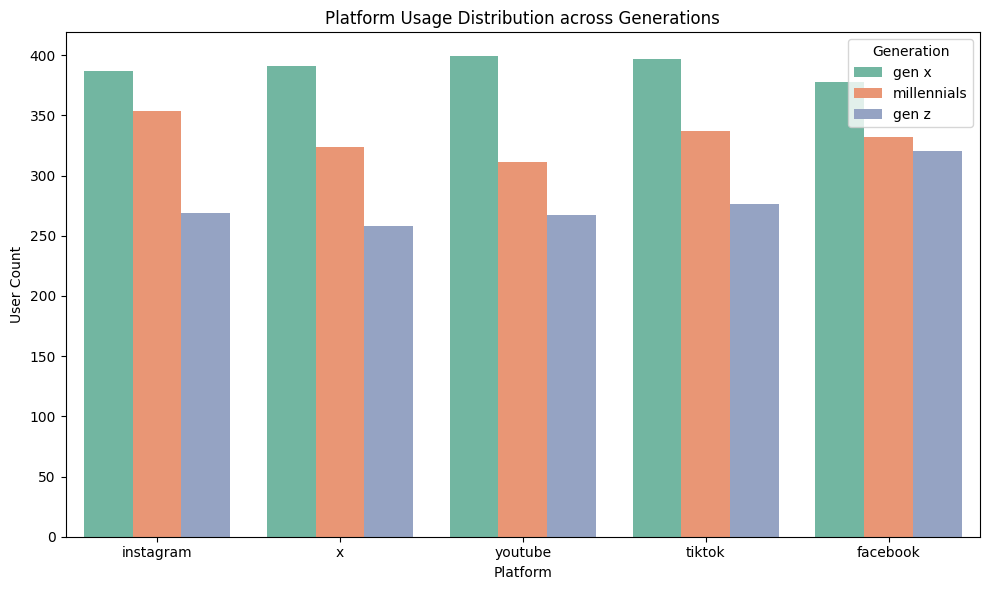

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset hasil Pentaho
df = pd.read_csv('/Users/erwina/Desktop/LEONARDO/Research Methodology/social_media_ready_for_ML (1).csv')

# Membersihkan spasi
df['age_category'] = df['age_category'].astype(str).str.strip().str.lower()
df['platform'] = df['platform'].astype(str).str.strip().str.lower()

# 1. Membuat Tabel Distribusi Platform per Generasi
platform_gen_table = pd.crosstab(df['age_category'], df['platform'], margins=True)
print("--- TABEL DISTRIBUSI PLATFORM PER GENERASI ---")
print(platform_gen_table)

# 2. Membuat Visualisasi agar bagus di paper
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='platform', hue='age_category', palette='Set2')
plt.title('Platform Usage Distribution across Generations')
plt.xlabel('Platform')
plt.ylabel('User Count')
plt.legend(title='Generation')
plt.tight_layout()
plt.savefig('eda_platform_generation.png')
print("\nGambar eda_platform_generation.png sudah disimpan.")